# Signal decomposition: Fourier Analysis

In [1]:
%%html
<!-- styling for the images -->
<style>
img { width:40vw; margin:0 auto; display:flex; }
</style>



In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. A simple sample

Suppose we have a function like the following:

\begin{equation}
f(t) = \sin(2\pi\cdot3t) + 1.5 \sin(2\pi\cdot5t) + \sin(2\pi\cdot8t)
\end{equation}

We can visualise this function as follows.

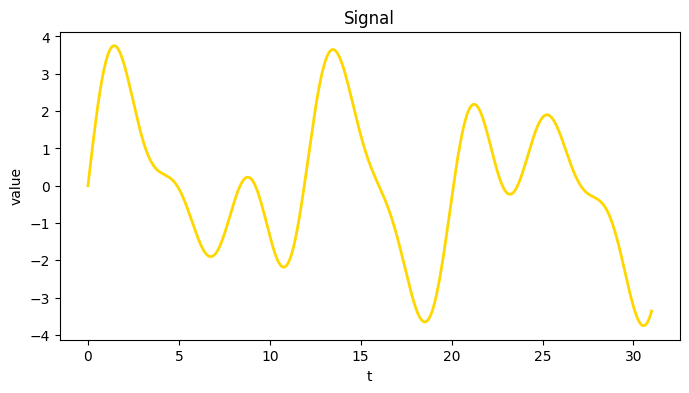

In [3]:
N = 32
n = np.arange(N)

# Fine grid for smooth plot
n_fine = np.linspace(0, N-1, 1000)
x_fine = (
    2.0 * np.sin(2 * np.pi * 3 * n_fine / N) +
    1.5 * np.sin(2 * np.pi * 5 * n_fine / N) +
    1.0 * np.sin(2 * np.pi * 8 * n_fine / N)
)

plt.figure(figsize=(8,4))

# Smooth continuous line
plt.plot(n_fine, x_fine, color='gold', linewidth=2, label='Measured signal')

plt.title("Signal")
plt.xlabel("t")
plt.ylabel("value")
plt.show()


Now how can we say anything interesting about this signal?

## 2. A combination of sines and cosines...

Any combination of a sine and a cosine wave with frequency $k$ is again a sinusoid with this frequency. The amplitude and phase of the oscillation depend on the relative components of the sine and the cosine contribution. Specifically:

\begin{equation}
a \times cos(2\pi ft) + b\times sin(2\pi ft) = c \times sin (2\pi ft + \phi)
\end{equation}

where $c = \sqrt{a^2 + b^2}$ and $\phi = tan^{-1}(b/a)$.

<img src='data/imgs/idea-fourier-transform.jpeg' style="width:300px;"/>


To transform a continuous function from the time domain to the frequency domain, one uses the Fourier Integral. A common convention is to indicate functions of time with lowercase variables, and functions of frequency with uppercase. So $X(f)$ is a function dependent on the *frequency* $f$, whereas $x(t)$ is a function dependent on the *time*, $t$. So:

\begin{equation}
X(f) = \int_{-\infty}^\infty x(t)e^{-i2\pi ft}dt
\end{equation}

where $-i$ is the imaginary unit ($i^2=-1$).

The inverse transform is given by

\begin{equation}
x(t) = \int_{-\infty}^\infty X(k)e^{i2\pi ft}df
\end{equation}


In practice, when working with digital representations of data sampled from a continuously varying signal, the data sets are not only time-limited but also discrete. For such data sets only a finite number of sinusoids are required to represent the signal. Specifically, for $n$ discrete data points only $n$ sinusoids are required to make up the signal. 

If $N$ data points were sampled with a constant sampling frequency, then the Fourier coeﬃcients $F[k]$ can be obtained with


\begin{equation}
X[k] = \sum_{n=0}^{N-1} x[n] \times e^{-z}  \text{ where } k = 0, 1, ... N-1
\end{equation}

where $z=i2\pi n \frac{k}{N}$. We call $F[k]$ the *k-th frequency bin* of the signal. Observe that when $n=0$, the value of this frequency bin is $1$. When $n=1$ the frequency bin is a complex number on the unit circle, with angle $−2 \pi k/N$. 
−2πk/N.

The inverse Fourier transform is given by

\begin{equation}
x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k \times e^{z}
\end{equation}



Let's look at our data in a more discrete manner. Asume that the signal is measured at 32 distinct intervals ($N=32)$.

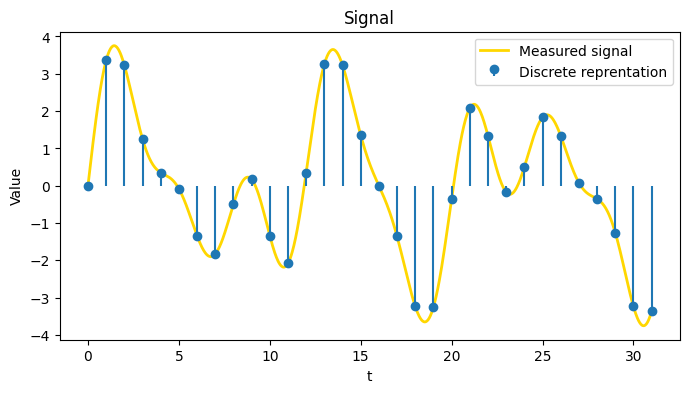

In [4]:
N = 32
n = np.arange(N)

x = (
    2.0 * np.sin(2 * np.pi * 3 * n / N) +
    1.5 * np.sin(2 * np.pi * 5 * n / N) +
    1.0 * np.sin(2 * np.pi * 8 * n / N)
)

n_fine = np.linspace(0, N-1, 1000)
x_fine = (
    2.0 * np.sin(2 * np.pi * 3 * n_fine / N) +
    1.5 * np.sin(2 * np.pi * 5 * n_fine / N) +
    1.0 * np.sin(2 * np.pi * 8 * n_fine / N)
)

plt.figure(figsize=(8,4))
plt.plot(n_fine, x_fine, color='gold', linewidth=2, label='Measured signal')
plt.stem(n, x, basefmt=" ", label='Discrete reprentation')
plt.title("Signal")
plt.xlabel("t")
plt.ylabel("Value")
plt.legend()
plt.show()

Let's compute $X[3]$, using the formula for the descrete fourier analysis above.

In [5]:
k = 3

X3 = 0
for n_val in range(N):
    X3 += x[n_val] * np.exp(-1j * 2 * np.pi * n_val * k / N)

print(type(X3))
print(X3)
print("Magnitude:", abs(X3))
print("Magnitude / N:", abs(X3) / N)

<class 'numpy.complex128'>
(1.865174681370263e-14-32.00000000000001j)
Magnitude: 32.00000000000001
Magnitude / N: 1.0000000000000002


You see that `X3` is actually a [complex number](https://en.wikipedia.org/wiki/Complex_number): a number that consist of a *real part* and an *imaginary part*, typically expressed in the form $a+bi$, where $a$ and $b$ are real numbers and $i$ is the imaginary unit defined as the square root of -1. That follows from the formula above (where $i$ was present in the exponent to $e$) and has to to with the representation of the amplitude and the phase shift of the corresponding Fourier component, compared to a pure cosine wave.

Each Fourier coefficient is a complex number, with a magnitude and a phase.

<img src="data/imgs/complex-number.jpeg" width="300">


You also can see that the `magnitude` of `X[3]` divided by $N$ is almost equal to one. Let's calculate another example, $X[4]$:

In [6]:
k = 4

X4 = 0
for n_val in range(N):
    X4 += x[n_val] * np.exp(-1j * 2 * np.pi * n_val * k  / N)

print("X[4] =", X4)
print("Magnitude:", abs(X4))
print("Magnitude / N:", abs(X4) / N)

X[4] = (-2.6645352591003757e-15+1.2878587085651816e-14j)
Magnitude: 1.3151340367799278e-14
Magnitude / N: 4.1097938649372744e-16


In [7]:
len(x)

32

As you see, in this case the division is almost equal to zero. This is how Fourier actually works: If the frequency of 
$x[n]$ matches $k$, all the complex terms *line up* in roughly the same direction, and their sum has large magnitude. If, on the other hand, the frequency does not match, the terms rotate in many directions and mostly cancel out, producing a small magnitude.

Now, let's use [numpy's fft](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html) module to calculate the $k$'s for all the 32 observations, and plot the corresponding *frequency bins*:

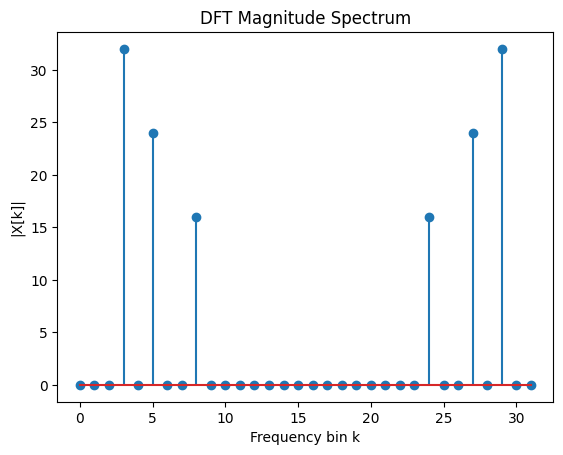

In [8]:
X = np.fft.fft(x)
magnitude = np.abs(X)

plt.stem(magnitude)
plt.title("DFT Magnitude Spectrum")
plt.xlabel("Frequency bin k")
plt.ylabel("|X[k]|")
plt.show()


## 3. A more complex example

Let's use this technique to analyse a more complex example. The following code allows you to play sound at the push of a button in this notebook. For a system-independent way to play sound in scripts, I recommend that you use the methods of *Sound* objects from the class *sksound.sounds.Sound* (from [scikit-sound](http://work.thaslwanter.at/sksound/html)).

In [9]:
from IPython.display import Audio, display
from scipy.io.wavfile import read
import sksound
import os

In [10]:
def play(x, fr, autoplay=False):
    display(Audio(x, rate=fr, autoplay=autoplay))
    

sound_file = 'data/a1.wav'
rate, data = read(sound_file)
play(data, rate)

In [11]:
#Let's get some information about the sound
m = len(data)
duration = m/rate

print(f'{data.dtype=}')
print('Mono sound') if len(data.shape)==1 else print ('Stereo sound')
print(f'Duration of recording: {duration:.2f} seconds')

data.dtype=dtype('int16')
Mono sound
Duration of recording: 2.46 seconds


In [12]:
# For the next demos, we need some additional variables:
sound_time = range(7_000, 20_000)
time_slice = [0.175, 0.185]

# I'm reloading the  file, because I want to have it as a Sound-object.
sound = sksound.sounds.Sound('data/a1.wav')

# We normalise the data using min-max-scaling
a1 = sound.data[sound_time]
a1_range = a1.max() - a1.min()
a1 = a1 / a1_range
time = np.arange(len(a1))/sound.rate

data read in!


If we just plot the data, you cannot make real chocolate of it. It just appears as some highly-variadic function of pressure over time. It could be a moving microphone or a diminishing something. Even if we zoom in into the signal (right image below), it's not immediately clear what is happening.

[Text(0, -0.6000000000000001, ''),
 Text(0, -0.4000000000000001, ''),
 Text(0, -0.20000000000000007, ''),
 Text(0, 0.0, ''),
 Text(0, 0.19999999999999996, ''),
 Text(0, 0.3999999999999999, ''),
 Text(0, 0.6000000000000001, '')]

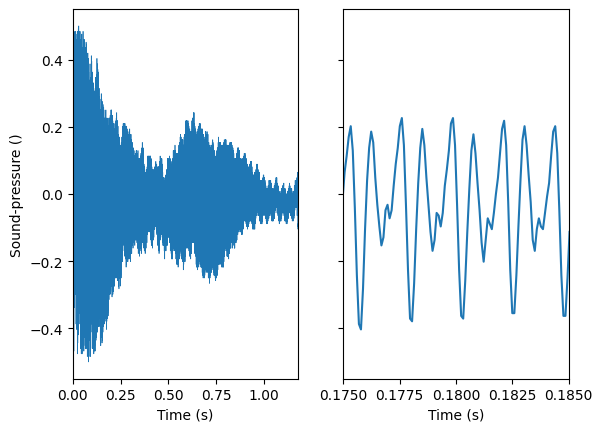

In [13]:
fig, axs = plt.subplots(1,2)
axs[0].plot(time, a1, lw=0.5)
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Sound-pressure ()')
axs[0].margins(x=0)

axs[1].plot(time, a1)
axs[1].set_xlim(time_slice)
axs[1].set_xlabel('Time (s)')
axs[1].set_yticklabels([])      



In [14]:
len(data)

27071

We have a function (signal) of pressure over time, but what we *want* is a function of value over *frequency*. This is exactly what the Fourier transformation is doing, so let's use this technique on our data.

In [15]:
# Fourier Transformation of the data
# Here we use the function "fft" from the package "np.fft"
fft_data = np.fft.fft(data)

# The Powerspectrum only contains the magnitude of the Fourier components
# Note: The casting to real is only to eliminate an annoying Warning message
Pxx = np.real(fft_data * fft_data.conj()) / m
freq = np.arange(m)/duration

#print(type(fft_data[0]))
print(len(freq))

27071


Now, we calculate the Nyquist-frequency of the signal. From [wikipedia](https://en.wikipedia.org/wiki/Nyquist_frequency): In signal processing, the Nyquist frequency (or folding frequency) is a characteristic of a sampler, which converts a continuous function or signal into a discrete sequence. For a given sampling rate (samples per second), the Nyquist frequency (cycles per second) is the frequency whose cycle-length (or period) is twice the interval between samples, thus 0.5 cycle/sample. 

(0.0, 5512.296368807949)

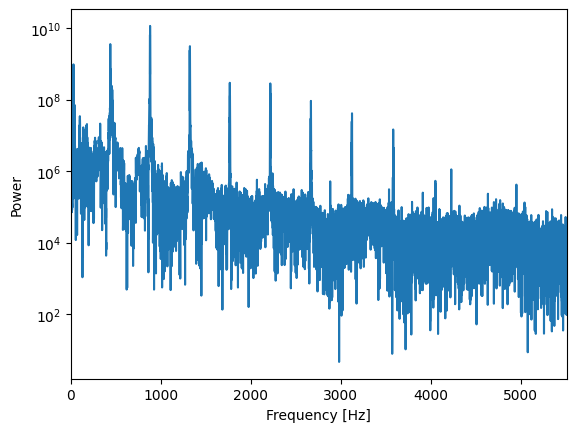

In [16]:
# Plot the data
plt.semilogy(freq, Pxx)

plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
Nyquist = max(freq)/2
plt.xlim(0, Nyquist)

If you plot the values of the *frequency bins* in these Nyquist frequencies, you can see something interesting happening. Instead of the hightly variadic function that we started with, now we see a *decomposition* of the signal into several constituent frequencies.

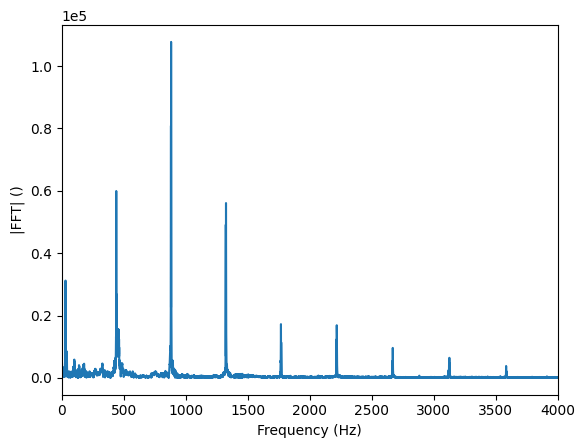

In [17]:
ax = plt.gca()
ax.set_xlim([0, 4_000])
plt.plot(freq, np.sqrt(Pxx))
#plt.set_xlim([0, 4000])
plt.xlabel('Frequency (Hz)')
plt.ylabel('|FFT| ()')
plt.ticklabel_format(style='sci', scilimits=(0, 4))

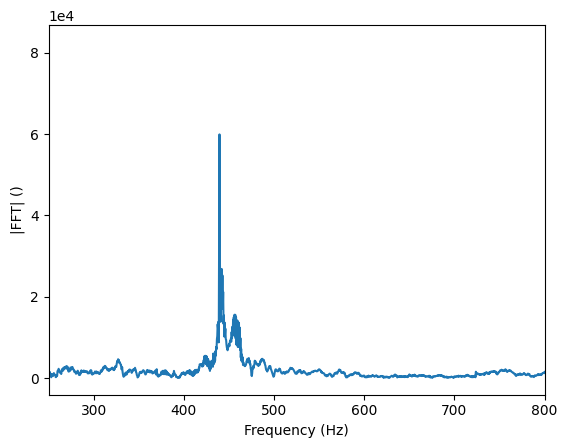

In [18]:
# Let's zoom in a little bit...
ax = plt.gca()
ax.set_xlim([250, 800])
plt.plot(freq[:2_000], np.sqrt(Pxx)[:2_000])
#plt.set_xlim([0, 4000])
plt.xlabel('Frequency (Hz)')
plt.ylabel('|FFT| ()')
plt.ticklabel_format(style='sci', scilimits=(0, 4))

In [19]:
# Let's find the index of the highest value
np.argmax(np.sqrt(Pxx[100:2_000]))

np.int64(979)

In [20]:
# and find its frequence...
freq[979]

np.float64(398.70987403494513)

Almost 400Hz. We know that the main A is [usually tuned to 440Hz](https://en.wikipedia.org/wiki/A440_(pitch_standard)), so there we have it...

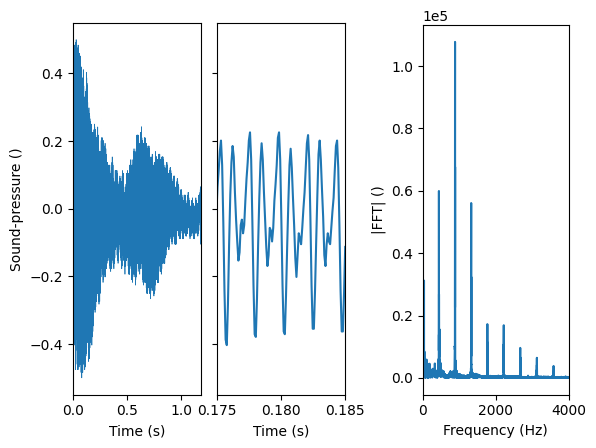

In [21]:
# Now, let's plot the whole shebang in one graph

fig, axs = plt.subplots(1,3)
axs[0].plot(time, a1, lw=0.5)
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Sound-pressure ()')
axs[0].margins(x=0)

axs[1].plot(time, a1)
axs[1].set_xlim(time_slice)
axs[1].set_xlabel('Time (s)')
axs[1].set_yticklabels([])      

axs[2].plot(freq, np.sqrt(Pxx))
axs[2].set_xlim([0, 4000])
axs[2].set_xlabel('Frequency (Hz)')
axs[2].set_ylabel('|FFT| ()')
axs[2].ticklabel_format(style='sci', scilimits=(0, 4))

# Position the plots
axs[0].set_position([0.125, 0.11, 0.2, 0.775])
axs[1].set_position([0.35, 0.11, 0.2, 0.775])

plt.show()

So by using Fourier Transformation we are able to change a function of values over time into a function of values of frequencies, and vice versa. Have a look at this nice animation from wikipedia:

<img src="https://upload.wikimedia.org/wikipedia/commons/7/72/Fourier_transform_time_and_frequency_domains_%28small%29.gif" alt="">

To make clear that one function is a fourier-transformation of another, it is practice to use $\stackrel{\mathcal{F}}{\Longleftrightarrow}$:

\begin{equation}
f(x) \stackrel{\mathcal{F}}{\Longleftrightarrow} \hat{f}(x)
\end{equation}



## 4. Applications


__Analysis of brain activity (EEG)__

![Image](https://ars.els-cdn.com/content/image/3-s2.0-B9780128044902000026-f02-01-9780128044902.jpg)

![Image](https://neuroimage.usc.edu/forums/uploads/default/original/1X/560fe408a916ffbe97f1c3d28a897161d273f4f1.jpg)

![Image](https://www.researchgate.net/publication/344882674/figure/fig5/AS%3A962245462872076%401606428604570/EEG-power-spectral-density-evolution-in-Patient-11-The-details-of-the-figure-are-the.png)

EEG measures electrical brain activity as a function of time. Using Fourier, we can change this into frequencies. We can use this for

* detection of epilepsy
* analysis of sleap stadia (delta-, theta-, alfa-, beta-waves)
* research to concentration and cognitive load
* Brain-computer interfaces


__Heart rhythm analysis__


![Image](https://d33v4339jhl8k0.cloudfront.net/docs/assets/5a3d2d0c042863193800368d/images/5b7583f70428631d7a8a0d08/file-gw3l5xmzCF.png)

![Image](https://www.researchgate.net/publication/327858932/figure/fig3/AS%3A674594847485952%401537847353315/Power-spectrum-of-a-typical-healthy-ECG-and-b-ECG-of-a-patient-with-Myocardial.png)


Using ECG we measure electrical activity of the heart. Using Fourier, we can

* locate cardiac arrhythmias
* analyse *Heart Rate Variability* (HRV)
* research autonomous sinew activity

High and loc frequency give information about stress and recovery

__Circadiane ritmes__

![Image](https://www.researchgate.net/publication/268504724/figure/fig1/AS%3A669032105668629%401536521092764/Human-24-Hour-Circadian-Rhythm-Source-National-Sleep-Foundation-2007.png)

![Image](https://www.researchgate.net/publication/323427109/figure/fig1/AS%3A598693673701378%401519751103710/Example-actigraphy-report-Example-actigraphy-report-participant-5-Sleep-patterns-are.png)

Lot of biological processes have a 24-hours rhythm:

* Hormone production
* Sleep-awake periods
* Genexpression

Using Fourier analysis we can see if the period is really 24 hours, check for distorted rhythms, or investigate jetlags etc.

__anything (in biology) that rills, oscillates or changes periodically, we can analyse using Fourier__
